### 카이제곱 검정

- 두 범주가 서로 관련성이 있는 지 여부를 판가름
- 관측 빈도와 기댓값을 비교해서 특정직인 부분 판단

In [ ]:
- 지금까지는 숫자를 비교
- 예) 성별에 따른 연령대 구성이 다른가? -> 

### 1. 질문에 해당하는 내용 확정, 교차표 작성
- 성별에 따른 연령대 구성이 다른가?
- 성별과 연령대의 빈도를 교차표로 작성


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

In [6]:
import pandas as pd
df = pd.read_csv("../data/07-9_bike_ttareungi.csv")
df.head(3)

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
0,202606,1201,1201. 가락시장역 3번 출구,정기권,NaN,30대,123,8750.55,78.97,339960.75,2621
1,202606,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173
2,202606,3928,3928.고척아이파크아파트 106동 앞,일일권,NaN,40대,7,444.12,4.00,17254.05,148


In [7]:
data = df.dropna(subset='성별')
data.head(3)

,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
1,202606,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173
3,202606,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66
4,202606,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220


In [14]:
table = pd.crosstab(data['성별'],data['연령대코드'])
table

연령대코드,20대,30대,40대,50대,60대,70대이상,~10대,기타
성별,,,,,,,,
F,243,281,256,218,145,48,271,44
M,262,254,252,254,186,115,316,43


### 2. 카이제곱 검정

In [ ]:
from scipy import stats

chi2, p, dof, expected = stats.chi2_contingency(table)
print("카이제곱검정", chi2)
print("p-value",p) # p값이 0.05 보다 작다 -> 성별과 연령대는 관련이 있다(독립이 아니다)
print("자유도",dof)

카이제곱검정 31.3133937658121
p-value 5.442025602370897e-05
자유도 7


In [16]:
p < 0.05

np.True_

In [18]:
f"{p:.5f}"

'0.00005'

### 3. 관측빈도 vs 기댓값
- 기댓값은 성별과 연령이 아무 관련이 없다면 나오는 빈도
- 관측빈도가 기댓값과 많이 다르다면 -> 그 연령대가 바로 특징적인 연령대

In [23]:
expected_df = pd.DataFrame(expected,
                            index=table.index,
                            columns=table.columns).round(2) #.astype(int)
expected_df

연령대코드,20대,30대,40대,50대,60대,70대이상,~10대,기타
성별,,,,,,,,
F,238.56,252.73,239.98,222.97,156.36,77.0,277.3,41.1
M,266.44,282.27,268.02,249.03,174.64,86.0,309.7,45.9


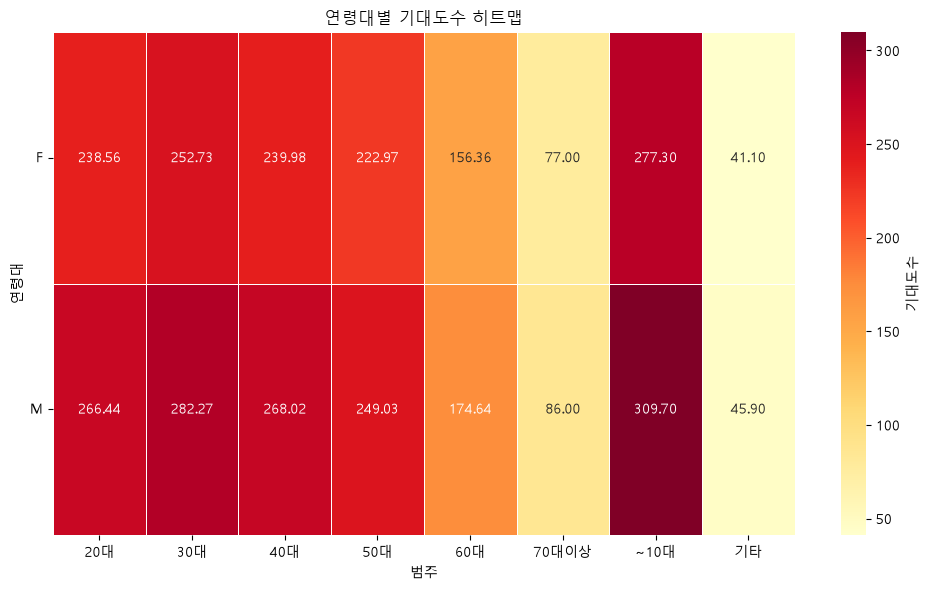

In [24]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    expected_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "기대도수"}
)

plt.title("연령대별 기대도수 히트맵")
plt.xlabel("범주")
plt.ylabel("연령대")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 효과 크기
- p 값만으로는 부족
- 차이가 얼마나 큰지
- 표본이 얼마나 적은지

In [29]:



data = df.dropna(subset='성별')
data.head(3)




,대여일자,대여소번호,대여소명,대여구분코드,성별,연령대코드,이용건수,운동량,탄소량,이동거리(M),이용시간(분)
1,202606,5339,5339. 은빛1단지 아파트 앞,정기권,M,~10대,15,517.56,4.65,20107.79,173
3,202606,102,102. 망원역 1번출구 앞,가족권(2시간),M,~10대,1,181.72,1.64,7060.00,66
4,202606,2265,2265. 이수고가차도 남단,일일권,F,50대,6,660.63,5.96,25665.78,220


In [31]:
male = data[data['성별']=='M']['이용건수']
female = data[data['성별']=='F']['이용건수']

t, p = stats.ttest_ind(male, female, equal_var=False)
print('t', t)
print('p', round(p,6))

t 6.877884158343051
p 0.0


In [ ]:
### 효과크기 - 차이가 얼마나 크냐 - cohen's d
- 코헨디 -> 평균차이를 표준편차로 나눈 값
- 코헨디 값이 0.2 작다
- 코헨디 값이 0.5 중간
- 코헨디 값이 0.8 크다

In [33]:
import numpy as np
pooled_std = np.sqrt(((len(male) - 1) * male.var() + (len(female) - 1) * female.var()) / (len(male) + len(female) - 2))
d = (male.mean() - female.mean()) / pooled_std

print("코헨디", d)

코헨디 0.23859778456906258


- 평균차이가 표준편차의 4분의 1수준이다 즉 -> 차이가 작다